<a href="https://colab.research.google.com/github/hsb-ctrl-zy/multi-team1-project/blob/main/%EC%BD%94%EB%9E%A9/%EC%9D%B4%EB%AF%B8%EC%A7%80_ALT_%EB%B9%84%EA%B5%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 대기업 vs 소상공인 이미지 Alt 속성 분석

### 필요 라이브러리 설치 및 로드

In [1]:
!pip install pymysql

In [2]:
import pymysql

### SQL 연결

In [3]:
#MySQL 연결 정보 설정
host_name='211.212.230.86'
user_name='teamuser'
password_val='1638'
db_name='geo_db'
port_num=3306

#데이터베이스 연결
conn=pymysql.connect(
    host=host_name,
    user=user_name,
    password=password_val,
    database=db_name,
    port=port_num,
    charset='utf8'
)

### MySQL 연결 상태 확인

In [4]:
if conn:
    try:
        # 커서를 생성하여 쿼리 실행 준비
        with conn.cursor() as cursor:
            # 간단한 쿼리로 현재 연결된 데이터베이스 이름을 확인
            cursor.execute("SELECT DATABASE();")
            result = cursor.fetchone()
            if result and result[0]:
                print(f"데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: {result[0]}")
            else:
                print("데이터베이스에 연결되었지만, 현재 데이터베이스 이름을 가져올 수 없습니다.")
    except pymysql.Error as e:
        print(f"데이터베이스 연결 확인 중 오류 발생: {e}")
        print("연결에 문제가 있을 수 있습니다.")
else:
    print("데이터베이스 연결 객체(conn)가 생성되지 않았습니다. 연결이 실패했을 수 있습니다.")

데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: geo_db


In [5]:
import json
import pandas as pd

### raw_data_table에서 image_text 컬럼 데이터 로드 및 전처리

In [6]:
try:
    with conn.cursor() as cursor:
        # raw_data_table에서 image_text 컬럼 데이터 가져오기
        cursor.execute("SELECT image_text FROM raw_data_table WHERE image_text IS NOT NULL AND image_text != '';")
        image_text_data = cursor.fetchall()

        # 데이터프레임으로 변환
        df_image_text = pd.DataFrame(image_text_data, columns=['image_text'])

        print(f"raw_data_table에서 로드된 유효한 image_text 행 수: {len(df_image_text)}")
        display(df_image_text.head())

except pymysql.Error as e:
    print(f"raw_data_table에서 데이터 로드 중 오류 발생: {e}")

raw_data_table에서 로드된 유효한 image_text 행 수: 6203


,image_text
0,타미진 장원영 PICK\n인기의류 / 슈즈 특가\n더 보러가기 >\n지오다노 X 롯...
1,타미진 장원영 PICK\n인기의류 / 슈즈 특가\n더 보러가기 >\n지오다노 X 롯...
2,디자이너 브랜드 혜택\n던스트 / 제너럴아이디어\n최대 42%쿠폰 단독혜택\n더 보...
3,아디다스언더웨어 단독구성\n브라팬티/드로즈/트렁크 외\n더 보러가기 >\n데일리템 ...
4,"가벼워서 더 시원한, 아이스 쿨링 소재\n아이스 냉감 7부 반바지\n(기본형|지퍼형..."


### diagnosis_table에서 raw_detail 컬럼 데이터 로드 및 전처리

In [7]:
try:
    with conn.cursor() as cursor:
        # diagnosis_table에서 raw_details 컬럼 데이터 가져오기
        cursor.execute("SELECT raw_details FROM diagnosis_table WHERE raw_details IS NOT NULL AND raw_details != '';")
        raw_detail_data = cursor.fetchall()

        # 데이터프레임으로 변환
        df_raw_detail = pd.DataFrame(raw_detail_data, columns=['raw_details'])

        print(f"diagnosis_table에서 로드된 유효한 raw_details 행 수: {len(df_raw_detail)}")
        display(df_raw_detail.head())

except pymysql.Error as e:
    print(f"diagnosis_table에서 데이터 로드 중 오류 발생: {e}")

diagnosis_table에서 로드된 유효한 raw_details 행 수: 8763


,raw_details
0,"{""details"": {""json_ld"": {""is_valid"": true, ""tr..."
1,"{""details"": {""json_ld"": {""is_valid"": true, ""tr..."
2,"{""details"": {""json_ld"": {""is_valid"": true, ""tr..."
3,"{""details"": {""json_ld"": {""is_valid"": true, ""tr..."
4,"{""details"": {""json_ld"": {""is_valid"": true, ""tr..."


### `raw_details` 컬럼의 JSON 구조 확인

In [8]:
print("df_raw_detail의 'raw_details' 컬럼 상위 2개 값:")
for i, row in df_raw_detail.head(2).iterrows():
    print(f"--- Row {i} ---")
    try:
        # JSON 문자열을 파싱하여 가독성 좋게 출력
        parsed_json = json.loads(row['raw_details'])
        print(json.dumps(parsed_json, indent=2, ensure_ascii=False))
    except json.JSONDecodeError as e:
        print(f"JSON 파싱 오류: {e}")
        print(row['raw_details'])

df_raw_detail의 'raw_details' 컬럼 상위 2개 값:
--- Row 0 ---
{
  "details": {
    "json_ld": {
      "is_valid": true,
      "trust_count": 0,
      "trust_score": 0.0,
      "density_score": 0.35,
      "parsing_score": 0.7,
      "clothing_score": 0.25,
      "present_attrs_count": 1
    },
    "image_alt": {
      "is_valid": true,
      "detail_results": [
        {
          "clean_alt": "타미진 띠배너",
          "final_score": 0.5,
          "is_stuffing": true,
          "has_alt_attribute": true,
          "s1_presence_score": 0.2,
          "s3_sentence_score": 0.0,
          "s2_relevance_score": 0.3
        },
        {
          "clean_alt": "캐쥬얼 지오다노 상품상세배너",
          "final_score": 0.5,
          "is_stuffing": true,
          "has_alt_attribute": true,
          "s1_presence_score": 0.2,
          "s3_sentence_score": 0.0,
          "s2_relevance_score": 0.3
        },
        {
          "clean_alt": "",
          "final_score": 0.0,
          "is_stuffing": false,
          "has

In [9]:
import json
import pandas as pd


# 1. JSON에서 유효한 clean_alt 개수만 세는 함수 정의
def extract_valid_alt_count(raw_details_json):
  try:
    data = json.loads(raw_details_json)
    # raw_details 내부의 detail_results 리스트 추출
    detail_results = (
        data.get("details", {}).get("image_alt", {}).get("detail_results", [])
    )

    # 의미 없는 Alt 텍스트 정의
    meaningless_terms = {"이미지", "상품 사진", "", " "}

    # clean_alt가 존재하고, 공백 제거 후 의미 없는 문자열이 아닌 항목만 필터링
    valid_alts = [
        item.get("clean_alt")
        for item in detail_results
        if item.get("clean_alt")
        and item.get("clean_alt").strip() not in meaningless_terms
    ]
    return len(valid_alts)
  except (json.JSONDecodeError, AttributeError):
    return 0


# 2. DB 데이터 로드 및 집계 처리
# conn이 성공적으로 연결된 경우에만 데이터 처리 실행
if conn:
  try:
    with conn.cursor() as cursor:
      # page_id 기준 JOIN 쿼리
      query = """
          SELECT
              d.page_id,
              d.raw_details,
              r.brand_type
          FROM diagnosis_table d
          INNER JOIN raw_data_table r ON d.page_id = r.page_id
          WHERE d.raw_details IS NOT NULL AND d.raw_details != ''
            AND r.brand_type IS NOT NULL AND r.brand_type != '';
          """
      cursor.execute(query)
      data = cursor.fetchall()

      # 데이터프레임 생성
      df = pd.DataFrame(data, columns=["page_id", "raw_details", "brand_type"])

      # 3. 유효한 ALT 속성 개수 계산
      df["valid_alt_count"] = df["raw_details"].apply(extract_valid_alt_count)

      # 4. brand_type별 페이지 수 및 평균 ALT 개수 계산
      result_df = (
          df.groupby("brand_type")["valid_alt_count"]
          .agg(["count", "mean"])
          .reset_index()
      )
      result_df.columns = ["brand_type", "페이지 수", "평균 유효 ALT 개수"]

      # 결과 출력
      display(result_df)

  except pymysql.Error as e:
    print(f"데이터베이스 조회 오류: {e}")
else:
  print("데이터베이스 연결 실패로 데이터 처리 건너뜀.")


,brand_type,페이지 수,평균 유효 ALT 개수
0,대기업,5750,3.681217
1,소상공인,3013,9.223034


In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

In [11]:
### Matplotlib 한글 폰트 설정 (깨짐 방지)

import matplotlib.pyplot as plt
import platform

# 운영체제에 맞는 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("Matplotlib 한글 폰트 설정 완료.")

Matplotlib 한글 폰트 설정 완료.


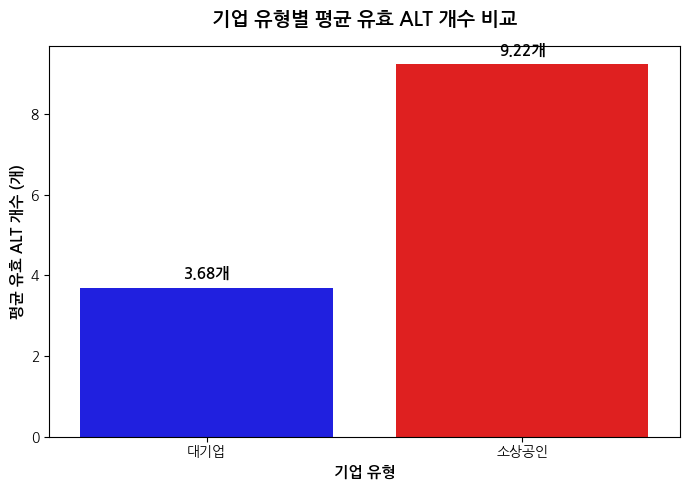

In [12]:
import seaborn as sns

#1. 그래프 크기 및 생성
plt.figure(figsize=(7, 5))

#2. 막대그래프 그리기
colors = ['blue','red']  # 대기업, 소상공인 색상 구분
ax = sns.barplot(
    data=result_df,
    x='brand_type',
    y='평균 유효 ALT 개수',
    palette=colors,
    hue='brand_type',
    legend=False,
)

#3. 그래프 세부 디자인 설정
plt.title(
    '기업 유형별 평균 유효 ALT 개수 비교',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('기업 유형', fontsize=11, fontweight='bold')
plt.ylabel('평균 유효 ALT 개수 (개)', fontsize=11, fontweight='bold')

#4. 막대 위에 정확한 수치 표시
for bar in ax.patches:
  height = bar.get_height()
  ax.annotate(
      f'{height:.2f}개',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 5),  # 텍스트 수직 오프셋
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
  )

plt.tight_layout()
plt.savefig('기업분류별 ALT.png')

plt.show()

## 브랜드별 이미지 Alt 속성 비교

In [13]:
#1. SQL 쿼리로 brand_name 추가 조회 및 JOIN
try:
  with conn.cursor() as cursor:
    query = """
        SELECT
            d.page_id,
            d.raw_details,
            r.brand_type,
            r.brand_name
        FROM diagnosis_table d
        INNER JOIN raw_data_table r ON d.page_id = r.page_id
        WHERE d.raw_details IS NOT NULL AND d.raw_details != ''
          AND r.brand_name IS NOT NULL AND r.brand_name != '';
        """
    cursor.execute(query)
    data = cursor.fetchall()

    df = pd.DataFrame(
        data, columns=["page_id", "raw_details", "brand_type", "brand_name"]
    )

    #2. 유효 ALT 개수 계산 (기존 정의된 extract_valid_alt_count 사용)
    df["valid_alt_count"] = df["raw_details"].apply(extract_valid_alt_count)

    #전체 브랜드별 평균 유효 ALT 개수 및 페이지 수 집계
    all_brand_result = (
        df.groupby(["brand_name", "brand_type"])["valid_alt_count"]
        .agg(["count", "mean"])
        .reset_index()
    )
    all_brand_result.columns = [
        "brand_name",
        "brand_type",
        "페이지 수",
        "평균 유효 ALT 개수"
    ]

    #평균 유효 ALT 개수 기준 내림차순 정렬
    brand_result = all_brand_result.sort_values(
        by="평균 유효 ALT 개수", ascending=False
    ).reset_index(drop=True)

    print(f"총 분석된 브랜드 수: {len(all_brand_result)}개")
    display(all_brand_result)

except pymysql.Error as e:
  print(f"DB 조회 중 오류 발생: {e}")

총 분석된 브랜드 수: 20개


,brand_name,brand_type,페이지 수,평균 유효 ALT 개수
0,613서울,소상공인,79,0.000000
1,CJ,대기업,2794,2.026843
2,LF,대기업,2527,4.861496
3,Uniqlo,대기업,429,7.503497
4,노드유,소상공인,179,10.972067
5,노티아,소상공인,71,1.507042
6,루프온,소상공인,282,37.705674
7,르아르,소상공인,97,0.000000
8,메리엣,소상공인,52,37.826923
9,미니포에,소상공인,100,0.000000


In [14]:
#1. 평균 유효 ALT 개수 소수점 정리 및 내림차순 정렬
brand_result = all_brand_result.sort_values(by="평균 유효 ALT 개수", ascending=False).reset_index(drop=True)
brand_result["평균 유효 ALT 개수"] = brand_result["평균 유효 ALT 개수"].round(2)

#2.전체 브랜드 결과 출력
print(f"=== 전체 브랜드 분석 결과 (총 {len(brand_result)}개 브랜드) ===")
display(brand_result)

=== 전체 브랜드 분석 결과 (총 20개 브랜드) ===


,brand_name,brand_type,페이지 수,평균 유효 ALT 개수
0,자스민벨,소상공인,280,38.00
1,메리엣,소상공인,52,37.83
2,루프온,소상공인,282,37.71
3,올라,소상공인,125,16.32
4,노드유,소상공인,179,10.97
5,Uniqlo,대기업,429,7.50
6,LF,대기업,2527,4.86
7,소버먼트,소상공인,128,3.20
8,CJ,대기업,2794,2.03
9,노티아,소상공인,71,1.51


In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

In [16]:
### Matplotlib 한글 폰트 설정 (깨짐 방지)

import matplotlib.pyplot as plt
import platform

# 운영체제에 맞는 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("Matplotlib 한글 폰트 설정 완료.")

Matplotlib 한글 폰트 설정 완료.


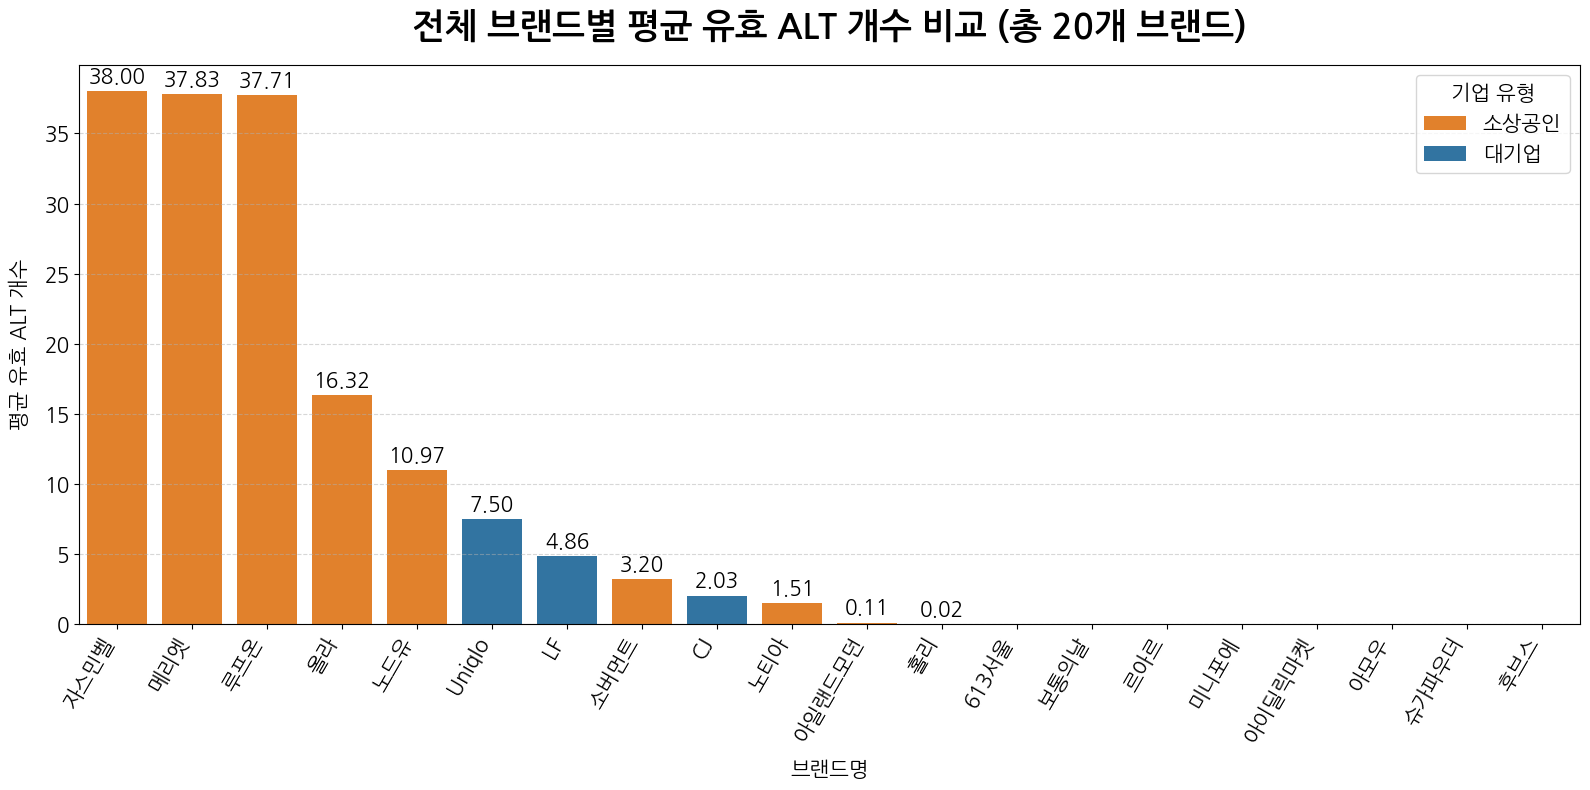

In [17]:
# 3. 전체 브랜드 시각화 (막대 그래프)
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=brand_result,
    x="brand_name",
    y="평균 유효 ALT 개수",
    hue="brand_type",
    dodge=False,
    palette={"대기업": "#1f77b4", "소상공인": "#ff7f0e"}
)

# 그래프 세부 설정
plt.title(f"전체 브랜드별 평균 유효 ALT 개수 비교 (총 {len(brand_result)}개 브랜드)", fontsize=25, fontweight="bold", pad=20)
plt.xlabel("브랜드명", fontsize=15, labelpad=10)
plt.ylabel("평균 유효 ALT 개수", fontsize=15, labelpad=10)
plt.yticks(fontsize=15)
plt.xticks(rotation=60, ha="right", fontsize=15)
plt.legend(title="기업 유형", title_fontsize="15", fontsize="15")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# 막대 상단에 수치(값) 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 0보다 큰 경우만 표시
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=15,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.tight_layout()
plt.show()

In [18]:
# 2. 기업 유형별 데이터 분리 및 정렬
df_large = all_brand_result[all_brand_result["brand_type"] == "대기업"].sort_values(
    by="평균 유효 ALT 개수", ascending=False
)
df_small = all_brand_result[all_brand_result["brand_type"] == "소상공인"].sort_values(
    by="평균 유효 ALT 개수", ascending=False
)

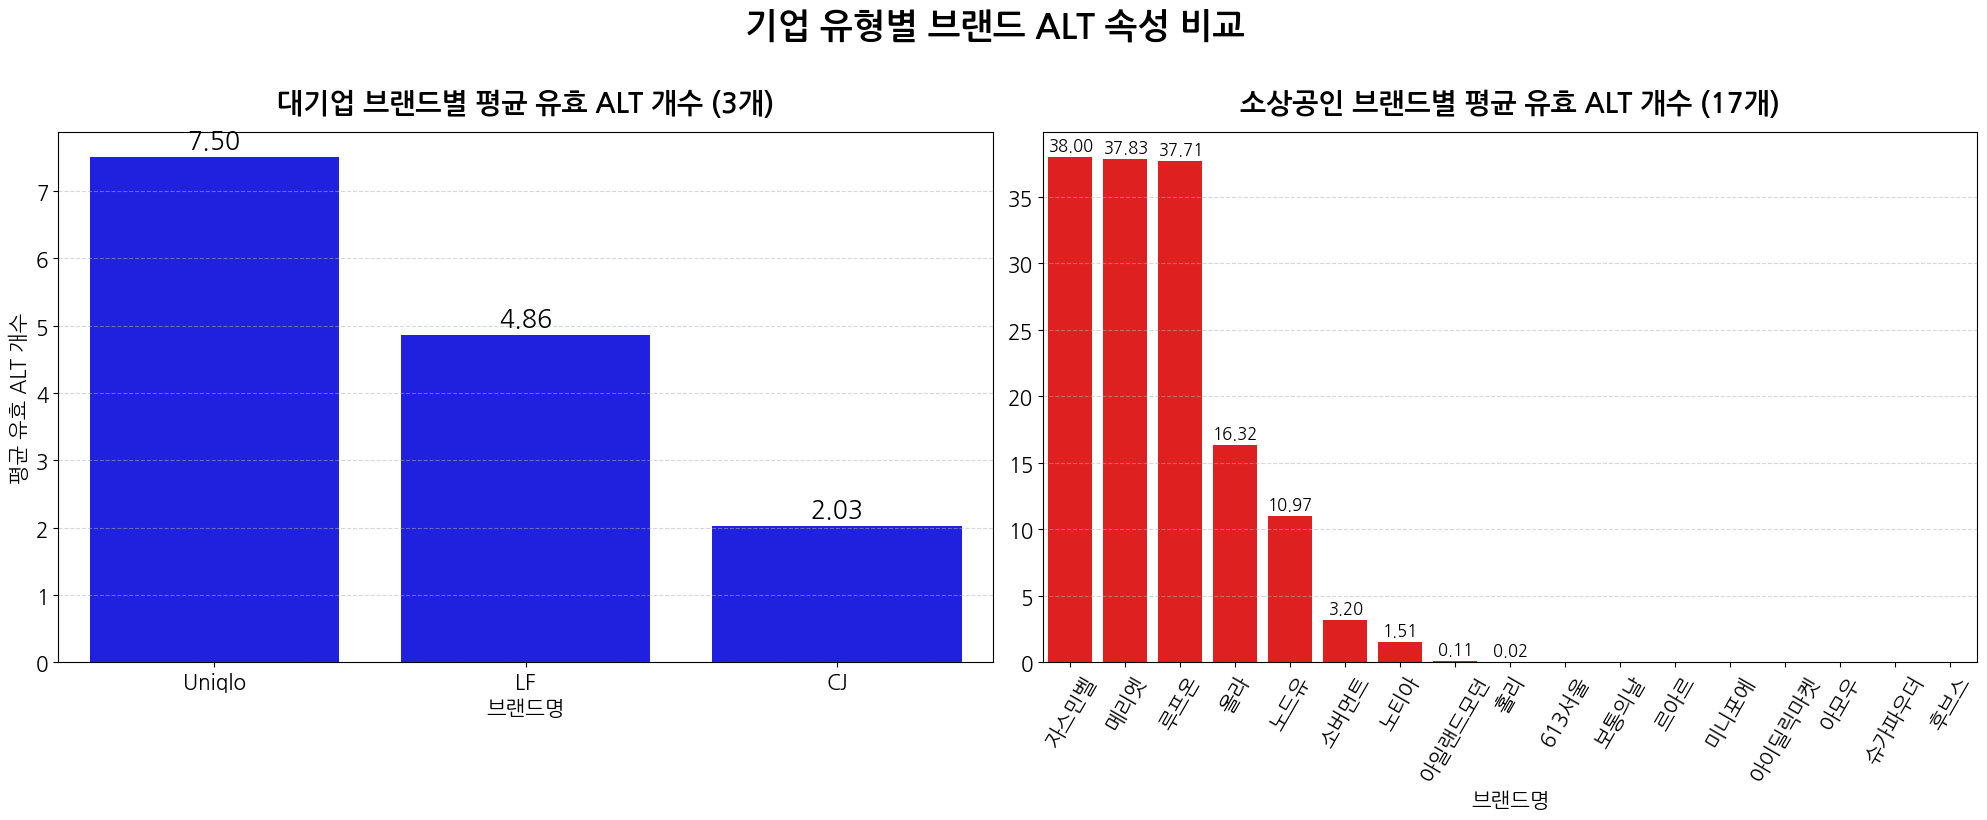

In [19]:
# 3. 1행 2열 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ----- [왼쪽] 대기업 브랜드 차트 -----
sns.barplot(
    data=df_large,
    x="brand_name",
    y="평균 유효 ALT 개수",
    ax=axes[0],
    color="blue"
)
axes[0].set_title(f"대기업 브랜드별 평균 유효 ALT 개수 ({len(df_large)}개)", fontsize=20, fontweight="bold", pad=15)
axes[0].set_xlabel("브랜드명", fontsize=15)
axes[0].set_ylabel("평균 유효 ALT 개수", fontsize=15)
axes[0].tick_params(axis="x", labelsize=15)
axes[0].tick_params(axis="y", labelsize=15)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# 값 수치 표시 (대기업)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center", va="bottom", fontsize=18, xytext=(0, 3), textcoords="offset points"
        )

# ----- [오른쪽] 소상공인 브랜드 차트 -----
sns.barplot(
    data=df_small,
    x="brand_name",
    y="평균 유효 ALT 개수",
    ax=axes[1],
    color="red"
)
axes[1].set_title(f"소상공인 브랜드별 평균 유효 ALT 개수 ({len(df_small)}개)", fontsize=20, fontweight="bold", pad=15)
axes[1].set_xlabel("브랜드명", fontsize=15)
axes[1].set_ylabel("")  # y축 레이블 중복 제거
axes[1].tick_params(axis="x", rotation=60,labelsize=15)
axes[1].tick_params(axis="y", labelsize=15)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# 값 수치 표시 (소상공인)
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center", va="bottom", fontsize=12, xytext=(0, 3), textcoords="offset points"
        )

plt.suptitle("기업 유형별 브랜드 ALT 속성 비교", fontsize=25, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig('브랜드별 유효 ALT.png')

plt.show()